# Quantitative Framework: WES vs in situ CNV

This notebook is a thin front-end to the manuscript's quantitative framework for validating CNV profiles.

It is meant for comparing one sample-specific in situ CNV profile against WES, while keeping all reusable framework code inside `insitucnv.tl.quantitative_validation`.


## Inputs

Edit the paths and settings below, then run the notebook from top to bottom.


In [1]:
from pathlib import Path

wes_file = Path('/home/augusta/storage3/augusta/insituCNV/data_from_Kang/sample_selection/WES_PureCN/WES_PureCN_output.csv')
#insitu_file = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/results/subclones/1105_K2_subclone_5_mean_cnv_per_gene.csv')
insitu_file = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/results/1105_BL_tumor_mean_cnv_per_gene.csv')

sample_name = '1105_BL'
saved_sample_name = '1105_BL_zscore'
bin_size_bp = 20_000_000
min_genes_per_bin = 5


In [2]:
import sys
import pandas as pd

repo_root = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from insitucnv.tl.quantitative_validation import (
    build_output_path,
    build_wes_insitu_comparison_table,
    compute_validation_metrics,
    load_gene_cnv_values,
    load_wes_segments,
    plot_confusion_matrix,
    plot_profile_comparison,
    plot_profile_comparison_lines,
    plot_threshold_scatter,
    plot_truth_overlay,
    rename_threshold_columns,
    resolve_wes_sample_id,
    save_dataframe,
    select_validation_thresholds,
)

NOTEBOOK_DIR = repo_root / 'Breast_cancer_Xenium5K/02_Compare_to_WES_metrics'
output_dir = NOTEBOOK_DIR / 'results'
output_dir.mkdir(parents=True, exist_ok=True)


## Load Data And Build Comparison Table


In [3]:
wes_sample_id = resolve_wes_sample_id(sample_name, wes_file)
wes = load_wes_segments(wes_file, wes_sample_id)
insitu = load_gene_cnv_values(insitu_file, value_col='CNV_value')

if not wes:
    raise ValueError(f'No WES rows found for {wes_sample_id}')
if not insitu:
    raise ValueError(f'No in situ rows found in {insitu_file}')

metric_df, axis = build_wes_insitu_comparison_table(
    wes=wes,
    insitu=insitu,
    bin_size_bp=bin_size_bp,
    min_genes_per_bin=min_genes_per_bin,
)

if metric_df.empty:
    raise ValueError('No comparison rows were created. Try fewer min_genes_per_bin or switch the comparison mode.')

comparison_title = (
    'Raw WES vs in situ comparison'
    if bin_size_bp is None
    else f'Binned WES vs in situ comparison (bin_size={bin_size_bp:,}, min_genes={min_genes_per_bin})'
)

print('Resolved sample mapping')
print('  WES sampleID   :', wes_sample_id)
print('  saved prefix   :', saved_sample_name)
print('  in situ file   :', insitu_file)
print('  WES segments   :', len(wes))
print('  in situ genes  :', len(insitu))
print('  comparison rows:', len(metric_df))
print('  output_dir     :', output_dir)

display(metric_df.head())


Resolved sample mapping
  WES sampleID   : UE-2971-1105-0
  saved prefix   : 1105_insitu_K2_vs_wes_BL
  in situ file   : /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/results/1105_K2_tumor_mean_cnv_per_gene.csv
  WES segments   : 244
  in situ genes  : 4798
  comparison rows: 146
  output_dir     : /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/02_Compare_to_WES_metrics/results


,mode,chr_num,start,end,x,wes_segmean,insitu_value,n_genes
0,binned,1,1,20000000,10000000.5,0.036722,0.010070,63
1,binned,1,20000001,40000000,30000000.5,0.019465,0.009795,82
2,binned,1,40000001,60000000,50000000.5,0.019465,0.032507,45
3,binned,1,60000001,80000000,70000000.5,0.019465,0.001791,21
4,binned,1,80000001,100000000,90000000.5,0.019465,0.000559,21


## Comparison Plots


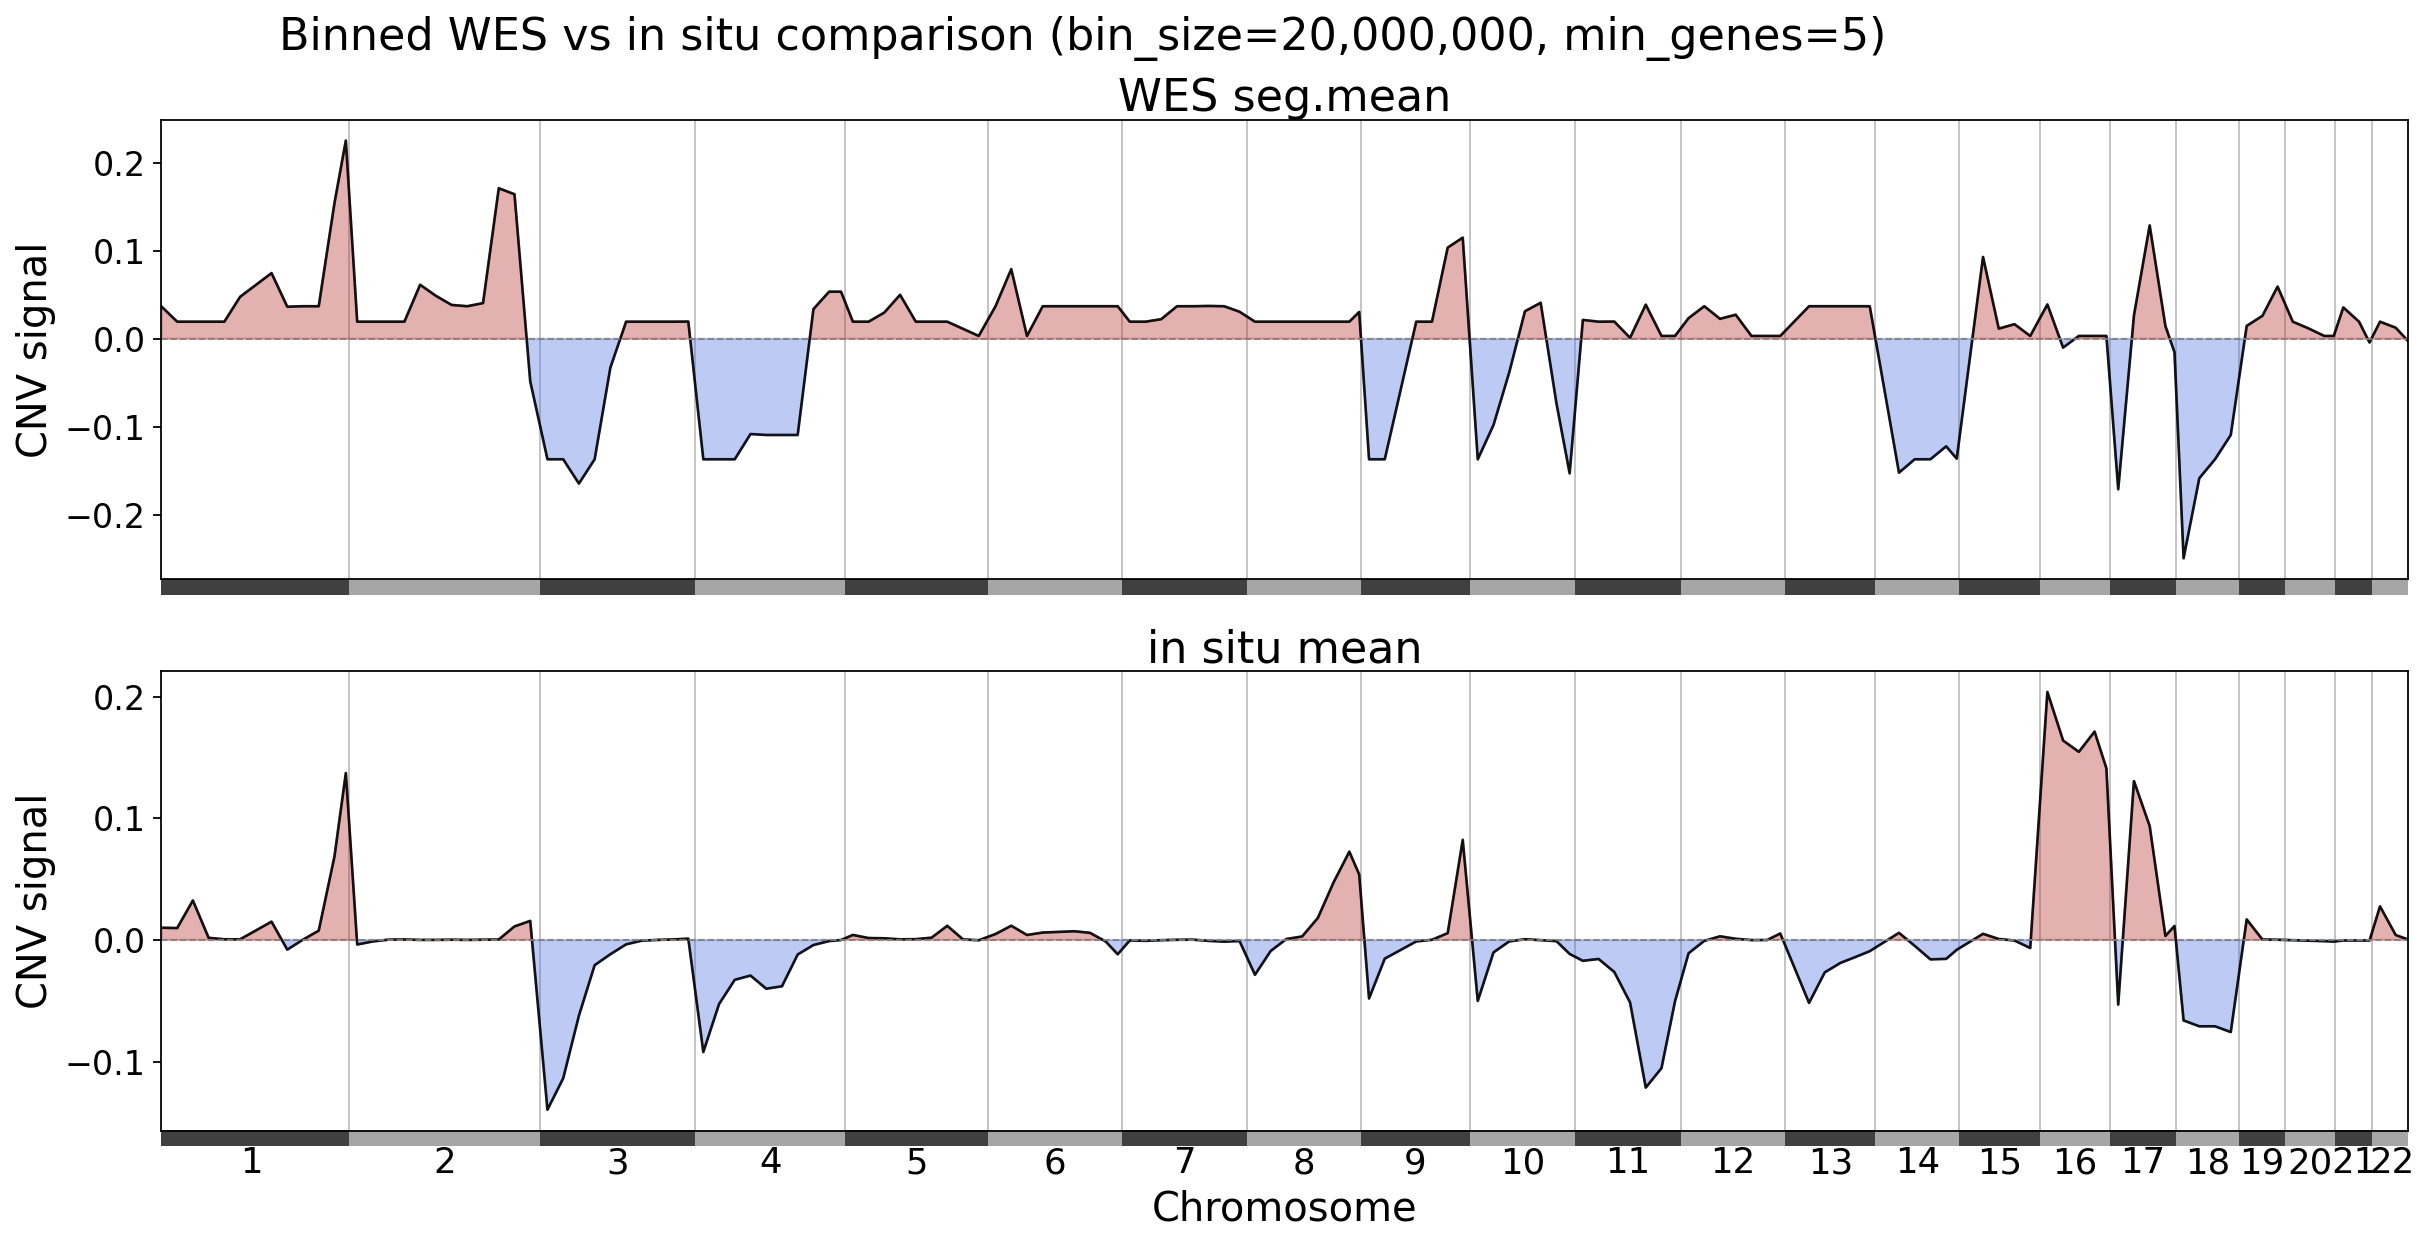

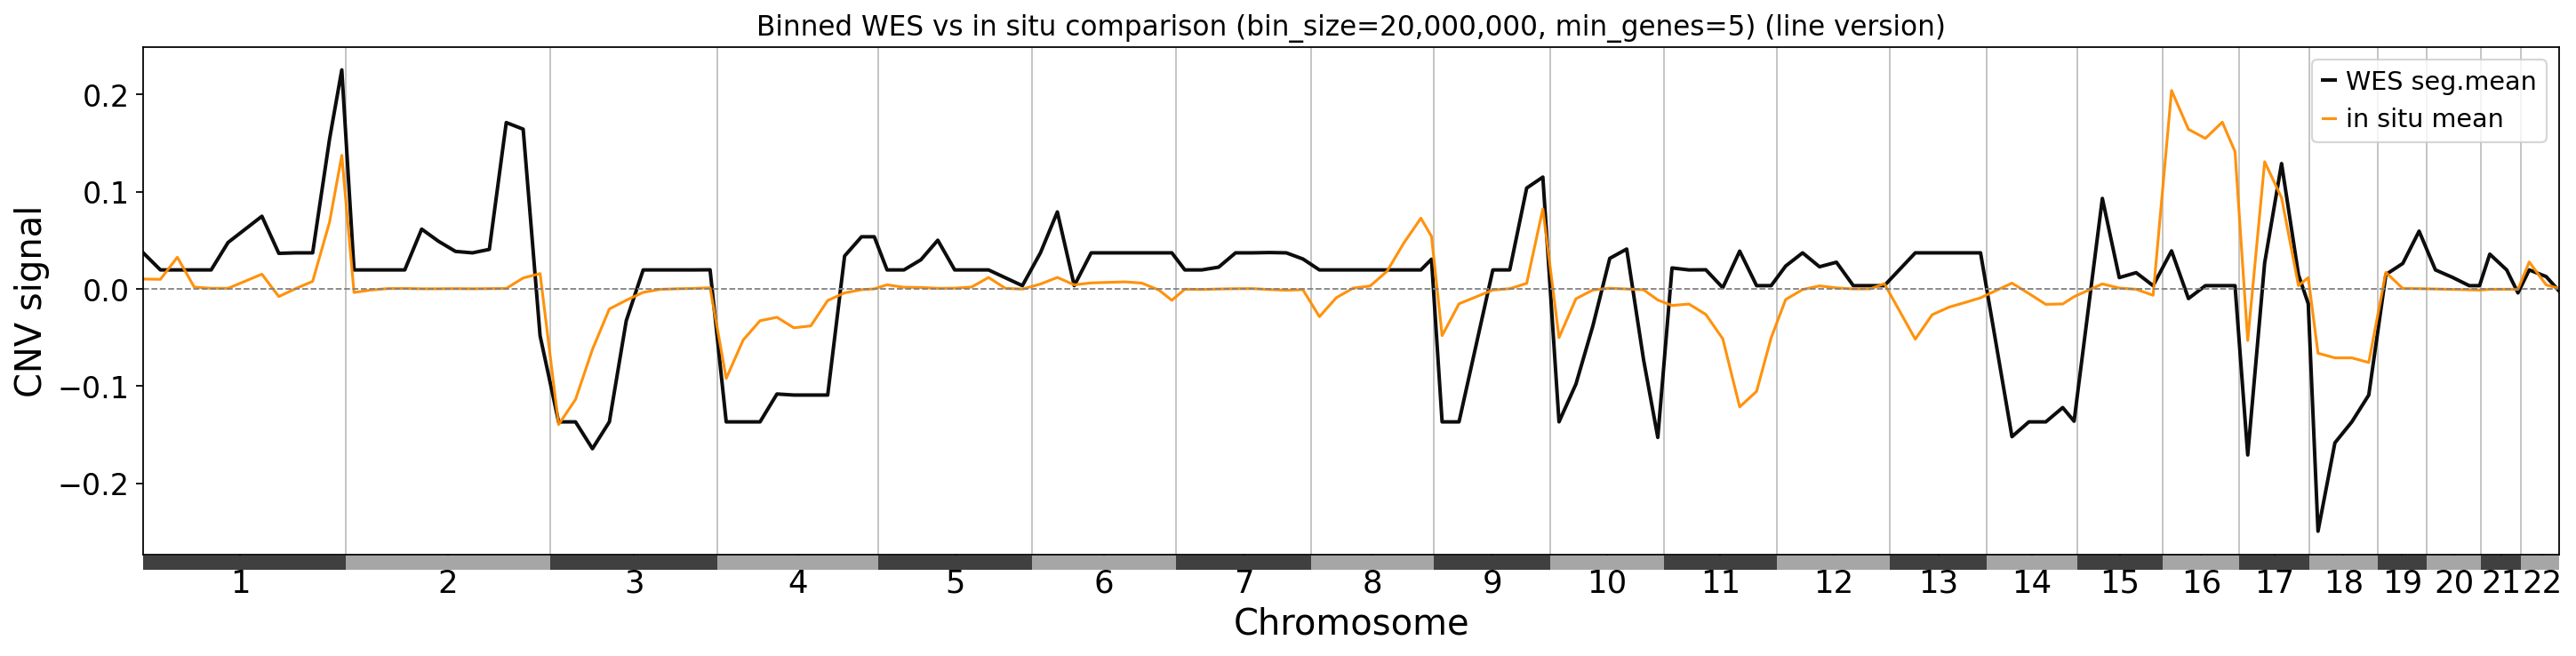

PosixPath('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/02_Compare_to_WES_metrics/results/1105insituK2vswesBL__comparison_plot_line.pdf')

In [4]:
plot_profile_comparison(
    metric_df=metric_df,
    offsets=axis['offsets'],
    chr_midpoints=axis['chr_midpoints'],
    truth_col='wes_segmean',
    pred_col='insitu_value',
    truth_label='WES seg.mean',
    pred_label='in situ mean' if bin_size_bp is not None else 'in situ value',
    title=comparison_title,
    ylabel='CNV signal',
    output_dir=output_dir,
    sample_name=sample_name,
    sample_prefix=saved_sample_name,
)

plot_profile_comparison_lines(
    metric_df=metric_df,
    offsets=axis['offsets'],
    chr_midpoints=axis['chr_midpoints'],
    truth_col='wes_segmean',
    pred_col='insitu_value',
    truth_label='WES seg.mean',
    pred_label='in situ mean' if bin_size_bp is not None else 'in situ value',
    title=comparison_title + ' (line version)',
    ylabel='CNV signal',
    output_dir=output_dir,
    sample_name=sample_name,
    sample_prefix=saved_sample_name,
)


## Threshold Selection

The framework uses the two-stage rule from the manuscript:

1. choose the WES threshold by maximizing mean gain/loss AUC
2. choose the in situ threshold by maximizing mean gain/loss F1 conditional on that WES threshold


In [5]:
wes_thr, insitu_thr, wes_threshold_grid_df, insitu_threshold_grid_df = select_validation_thresholds(
    metric_df=metric_df,
    truth_col='wes_segmean',
    pred_col='insitu_value',
    truth_threshold_name='wes_threshold',
    pred_threshold_name='insitu_threshold',
)

print('Selected thresholds')
print('  WES threshold    :', round(wes_thr, 6))
print('  in situ threshold:', round(insitu_thr, 6))

display(wes_threshold_grid_df.head(10))
display(insitu_threshold_grid_df.head(10))

save_dataframe(wes_threshold_grid_df, output_dir, sample_name, 'wes_threshold_auc_grid', index=False, sample_prefix=saved_sample_name)
save_dataframe(insitu_threshold_grid_df, output_dir, sample_name, 'insitu_threshold_f1_grid', index=False, sample_prefix=saved_sample_name)


Selected thresholds
  WES threshold    : 0.103615
  in situ threshold: 0.028625


,wes_threshold,auc_gain,auc_loss,auc_mean,n_truth_gain,n_truth_loss
0,0.103615,0.886905,0.920000,0.903452,6,25
1,0.108128,0.886905,0.920000,0.903452,6,25
2,0.109209,0.886905,0.915984,0.901444,6,24
3,0.097953,0.876670,0.918590,0.897630,7,26
4,0.074635,0.872668,0.918590,0.895629,9,26
5,0.079112,0.872668,0.918590,0.895629,9,26
6,0.061415,0.877941,0.912232,0.895086,10,27
7,0.073007,0.877941,0.912232,0.895086,10,27
8,0.092958,0.867754,0.918590,0.893172,8,26
9,0.114909,0.886905,0.896825,0.891865,6,20


,insitu_threshold,f1_gain,f1_loss,f1_mean,accuracy_3class
0,0.028625,0.400000,0.680851,0.540426,0.815068
1,0.029263,0.400000,0.666667,0.533333,0.815068
2,0.032507,0.400000,0.666667,0.533333,0.815068
3,0.026602,0.380952,0.680851,0.530902,0.808219
4,0.027623,0.380952,0.680851,0.530902,0.808219
5,0.032759,0.421053,0.636364,0.528708,0.815068
6,0.010953,0.344828,0.709677,0.527253,0.746575
7,0.015061,0.333333,0.714286,0.523810,0.780822
8,0.015346,0.333333,0.714286,0.523810,0.780822
9,0.018159,0.380952,0.666667,0.523810,0.794521


PosixPath('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/02_Compare_to_WES_metrics/results/1105insituK2vswesBL__insitu_threshold_f1_grid.csv')

## Metrics And Export


In [6]:
metrics_df, truth_labels, pred_labels = compute_validation_metrics(
    metric_df=metric_df,
    truth_thr=wes_thr,
    pred_thr=insitu_thr,
    truth_col='wes_segmean',
    pred_col='insitu_value',
    metadata={
        'sample_name': sample_name,
        'wes_sample_id': wes_sample_id,
        'mode': 'raw' if bin_size_bp is None else 'binned',
        'bin_size_bp': bin_size_bp,
        'min_genes_per_bin': min_genes_per_bin,
        'insitu_file': insitu_file.name,
    },
)
metrics_df = rename_threshold_columns(metrics_df, 'wes_threshold', 'insitu_threshold')
metric_df = metric_df.copy()
metric_df['truth'] = truth_labels
metric_df['pred'] = pred_labels

display(metrics_df)
save_dataframe(metrics_df, output_dir, sample_name, 'metrics_summary', index=False, sample_prefix=saved_sample_name)
save_dataframe(metric_df, output_dir, sample_name, 'comparison_rows', index=False, sample_prefix=saved_sample_name)

print('Saved:')
for stem, suffix in [
    ('comparison_plot', '.svg'),
    ('comparison_plot_line', '.svg'),
    ('metrics_summary', '.csv'),
    ('comparison_rows', '.csv'),
    ('wes_threshold_auc_grid', '.csv'),
    ('insitu_threshold_f1_grid', '.csv'),
]:
    print(' ', build_output_path(output_dir, sample_name, stem, suffix, sample_prefix=saved_sample_name))


,sample_name,wes_sample_id,mode,bin_size_bp,min_genes_per_bin,insitu_file,n_rows,wes_threshold,insitu_threshold,auc_gain,...,auc_mean,precision_gain,precision_loss,precision_mean,recall_gain,recall_loss,recall_mean,f1_gain,f1_loss,f1_mean
0,1105_BL,UE-2971-1105-0,binned,20000000,5,1105_K2_tumor_mean_cnv_per_gene.csv,146,0.103615,0.028625,0.886905,...,0.903452,0.285714,0.727273,0.506494,0.666667,0.64,0.653333,0.4,0.680851,0.540426


Saved:
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/02_Compare_to_WES_metrics/results/1105insituK2vswesBL__comparison_plot.svg
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/02_Compare_to_WES_metrics/results/1105insituK2vswesBL__comparison_plot_line.svg
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/02_Compare_to_WES_metrics/results/1105insituK2vswesBL__metrics_summary.csv
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/02_Compare_to_WES_metrics/results/1105insituK2vswesBL__comparison_rows.csv
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/02_Compare_to_WES_metrics/results/1105insituK2vswesBL__wes_threshold_auc_grid.csv
  /home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/02_Compare_to_WES_metrics/results/1105insituK2vswesBL__insitu_threshold_f1_grid.csv


## Diagnostic Plots


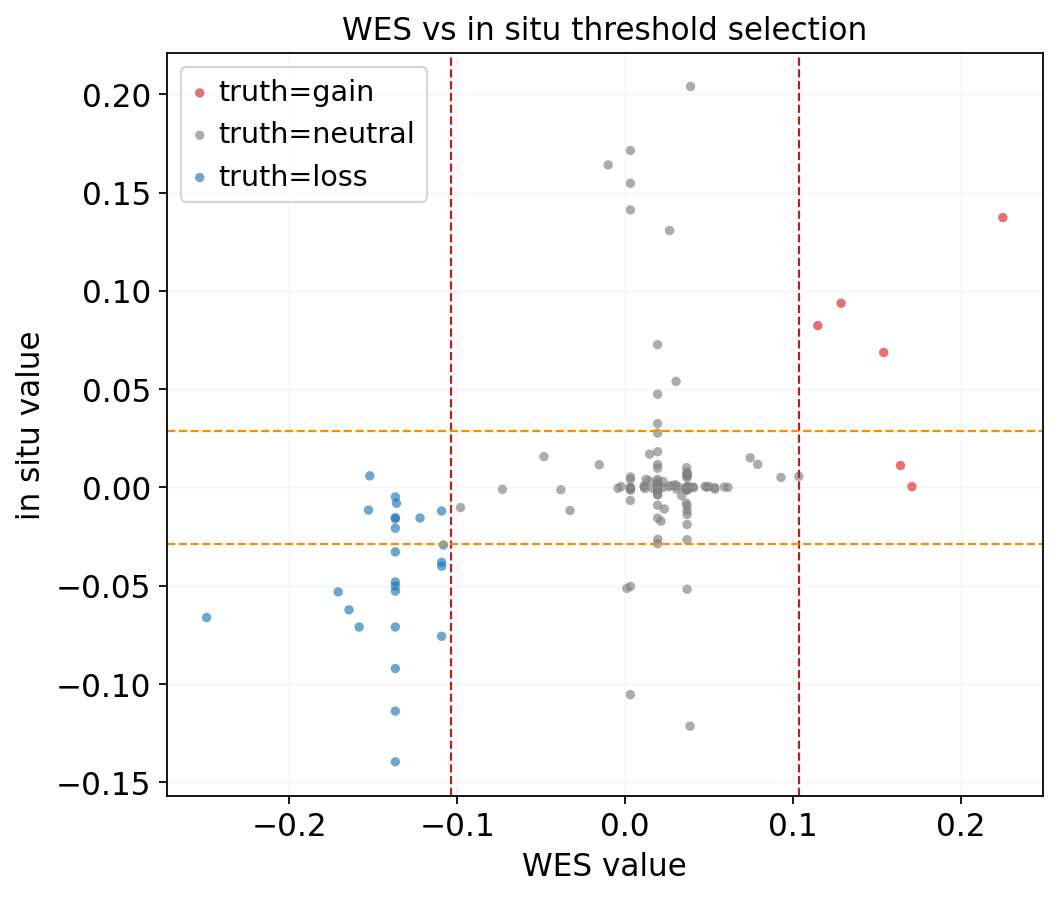

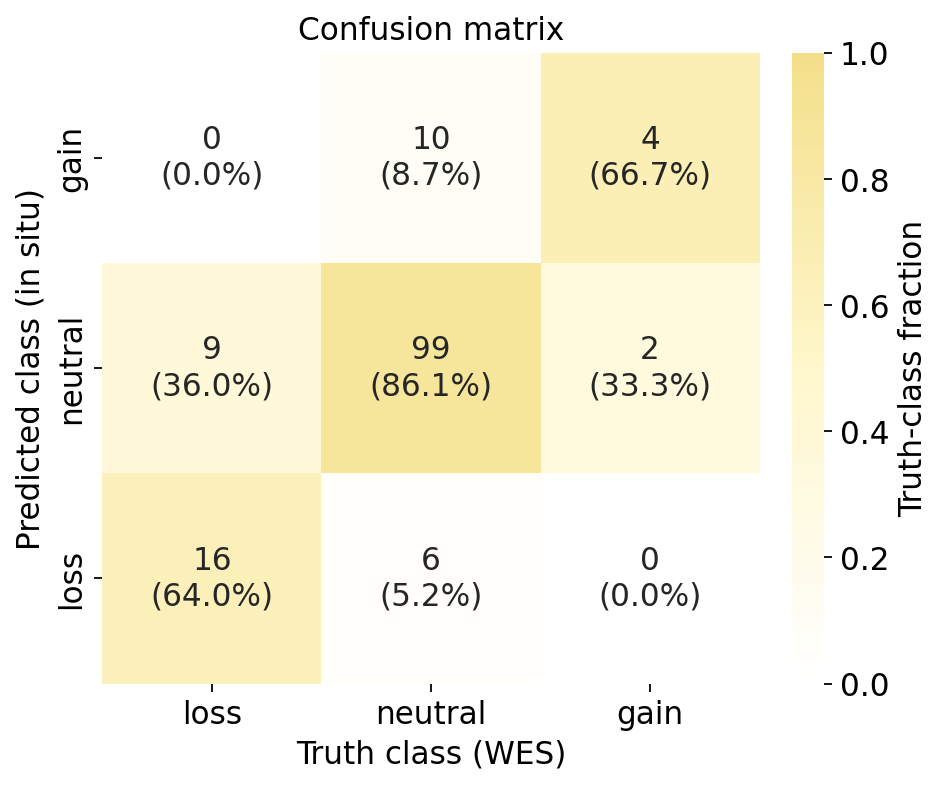

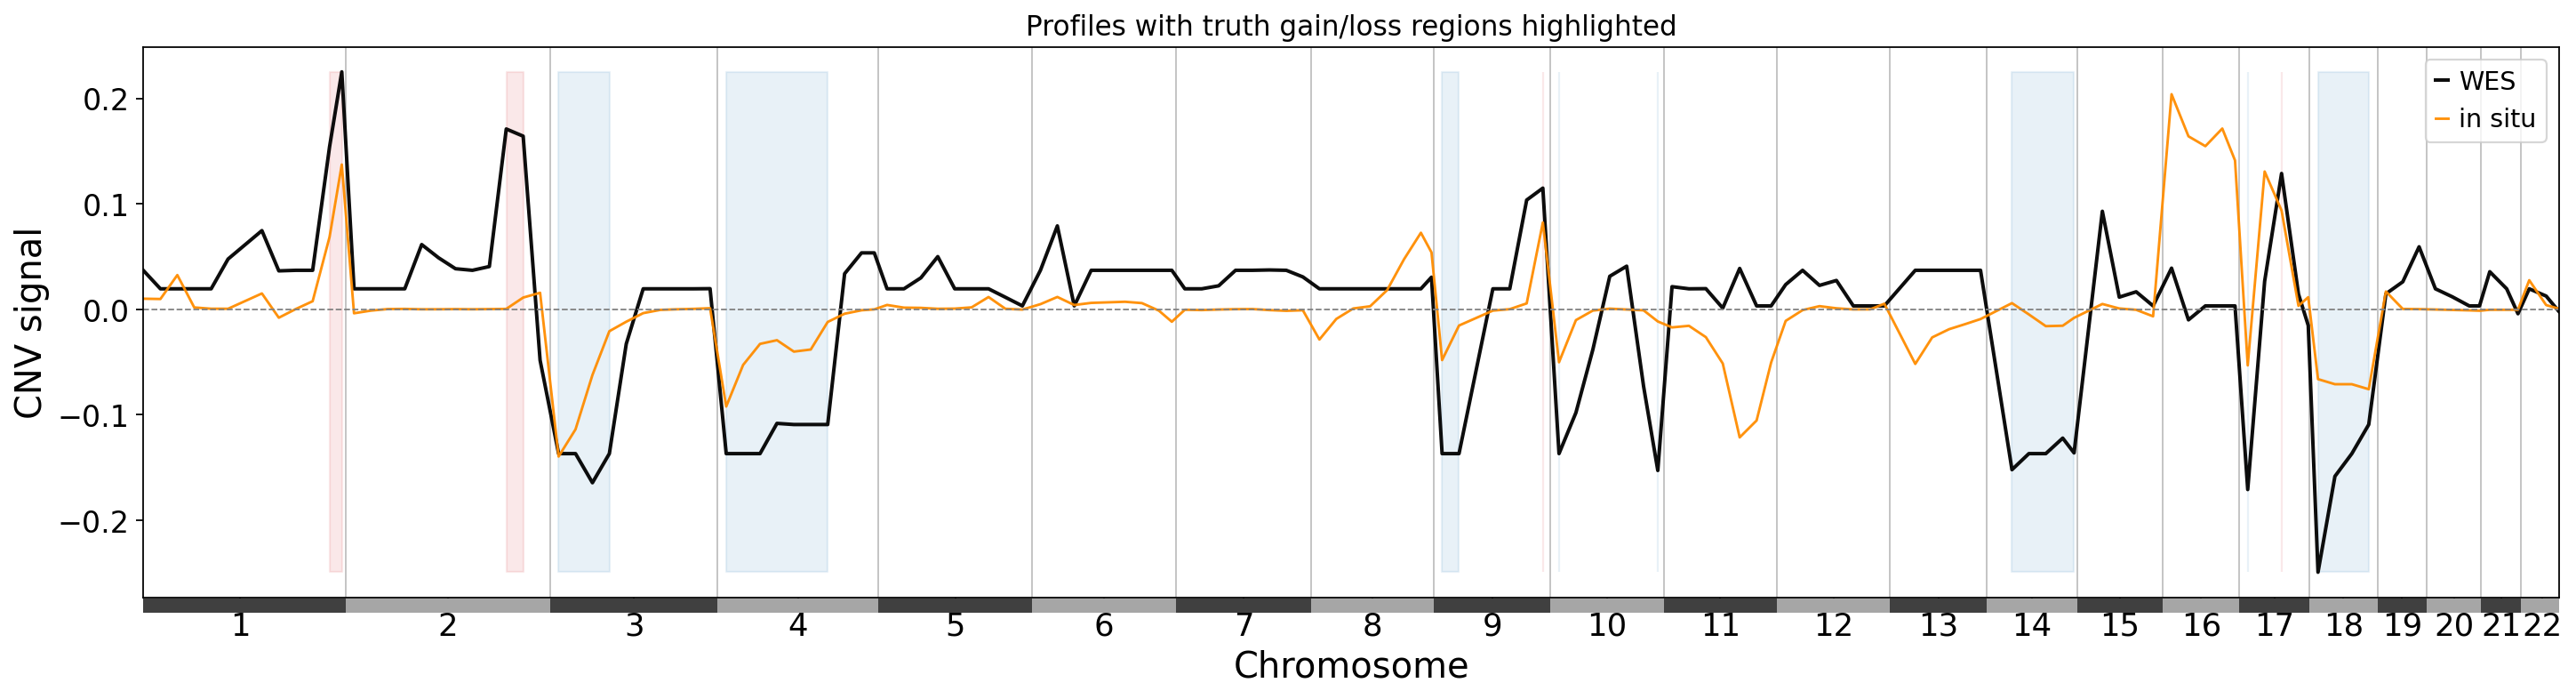

PosixPath('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/02_Compare_to_WES_metrics/results/1105insituK2vswesBL__confusion_matrix_row_pct.csv')

In [7]:
plot_threshold_scatter(
    metric_df=metric_df,
    truth_labels=truth_labels,
    truth_thr=wes_thr,
    pred_thr=insitu_thr,
    truth_col='wes_segmean',
    pred_col='insitu_value',
    truth_label='WES',
    pred_label='in situ',
    output_dir=output_dir,
    sample_name=sample_name,
    sample_prefix=saved_sample_name,
)

cm_counts_df, cm_pct_df = plot_confusion_matrix(
    truth_labels=truth_labels,
    pred_labels=pred_labels,
    truth_label='WES',
    pred_label='in situ',
    output_dir=output_dir,
    sample_name=sample_name,
    sample_prefix=saved_sample_name,
)

plot_truth_overlay(
    metric_df=metric_df,
    offsets=axis['offsets'],
    chr_midpoints=axis['chr_midpoints'],
    truth_col='wes_segmean',
    pred_col='insitu_value',
    truth_label='WES',
    pred_label='in situ',
    output_dir=output_dir,
    sample_name=sample_name,
    sample_prefix=saved_sample_name,
)

save_dataframe(cm_counts_df.reset_index().rename(columns={'index': 'truth'}), output_dir, sample_name, 'confusion_matrix_counts', index=False, sample_prefix=saved_sample_name)
save_dataframe(cm_pct_df.reset_index().rename(columns={'index': 'truth'}), output_dir, sample_name, 'confusion_matrix_row_pct', index=False, sample_prefix=saved_sample_name)
